In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not found")

CUDA available: True
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q torch torchvision torchaudio scikit-learn tqdm pandas

In [4]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [6]:
BASE_DIR = Path("/content")
WORK_DIR = BASE_DIR / "stanford_dogs_lab"
RAW_DIR = WORK_DIR / "raw"
SPLIT_DIR = WORK_DIR / "data"

DRIVE_DIR = Path("/content/drive/MyDrive/stanford_dogs_lab")
MODELS_DIR = DRIVE_DIR / "models"
RESULTS_DIR = DRIVE_DIR / "results"

WORK_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("WORK_DIR:", WORK_DIR)
print("RAW_DIR:", RAW_DIR)
print("SPLIT_DIR:", SPLIT_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

WORK_DIR: /content/stanford_dogs_lab
RAW_DIR: /content/stanford_dogs_lab/raw
SPLIT_DIR: /content/stanford_dogs_lab/data
MODELS_DIR: /content/drive/MyDrive/stanford_dogs_lab/models
RESULTS_DIR: /content/drive/MyDrive/stanford_dogs_lab/results


In [7]:
%cd /content/stanford_dogs_lab/raw

!wget -O images.tar http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
!tar -xf images.tar

/content/stanford_dogs_lab/raw
--2026-03-11 12:36:24--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘images.tar’

images.tar          100%[===================>] 756.82M  18.0MB/s    in 46s     

2026-03-11 12:37:10 (16.5 MB/s) - ‘images.tar’ saved [793579520/793579520]



In [8]:
images_root = Path("/content/stanford_dogs_lab/raw/Images")
print("Exists:", images_root.exists())

class_dirs = [p for p in images_root.iterdir() if p.is_dir()]
print("Number of classes:", len(class_dirs))
print("First 5 classes:", [p.name for p in class_dirs[:5]])

Exists: True
Number of classes: 120
First 5 classes: ['n02100735-English_setter', 'n02112706-Brabancon_griffon', 'n02107142-Doberman', 'n02094433-Yorkshire_terrier', 'n02088364-beagle']


In [9]:
def split_dataset(source_dir, dest_dir, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    random.seed(seed)

    source_dir = Path(source_dir)
    dest_dir = Path(dest_dir)

    for split in ["train", "val", "test"]:
        (dest_dir / split).mkdir(parents=True, exist_ok=True)

    class_folders = [p for p in source_dir.iterdir() if p.is_dir()]

    for class_folder in tqdm(class_folders, desc="Splitting classes"):
        images = list(class_folder.glob("*"))
        images = [img for img in images if img.is_file()]
        random.shuffle(images)

        n = len(images)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_imgs = images[:n_train]
        val_imgs = images[n_train:n_train+n_val]
        test_imgs = images[n_train+n_val:]

        for split_name, split_imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
            target_class_dir = dest_dir / split_name / class_folder.name
            target_class_dir.mkdir(parents=True, exist_ok=True)

            for img_path in split_imgs:
                target_path = target_class_dir / img_path.name
                if not target_path.exists():
                    shutil.copy(img_path, target_path)

    print("Dataset split completed.")

In [10]:
split_dataset(images_root, SPLIT_DIR)

Splitting classes: 100%|██████████| 120/120 [00:07<00:00, 15.30it/s]

Dataset split completed.


In [11]:
for split in ["train", "val", "test"]:
    split_path = SPLIT_DIR / split
    num_classes = len([p for p in split_path.iterdir() if p.is_dir()])
    num_images = sum(len(list(cls.glob("*"))) for cls in split_path.iterdir() if cls.is_dir())
    print(f"{split}: classes={num_classes}, images={num_images}")

train: classes=120, images=14355
val: classes=120, images=3025
test: classes=120, images=3200


In [12]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [13]:
train_ds = datasets.ImageFolder(SPLIT_DIR / "train", transform=train_tfms)
val_ds   = datasets.ImageFolder(SPLIT_DIR / "val", transform=eval_tfms)
test_ds  = datasets.ImageFolder(SPLIT_DIR / "test", transform=eval_tfms)

NUM_CLASSES = len(train_ds.classes)

print("Classes:", NUM_CLASSES)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))

Classes: 120
Train size: 14355
Val size: 3025
Test size: 3200


In [14]:
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders created successfully")

DataLoaders created successfully


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [17]:
def build_resnet50(num_classes, pretrained=True):
    if pretrained:
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
    else:
        model = models.resnet50(weights=None)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [19]:
@torch.no_grad()
def evaluate_loss_acc(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [20]:
def fit_model(model, train_loader, val_loader, device, epochs=5, lr=1e-4, optimizer_name="adam", save_name="temp_model"):
    criterion = nn.CrossEntropyLoss()

    model = model.to(device)

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
        swa_model = None
        swa_scheduler = None

    elif optimizer_name == "averaged_adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
        swa_model = AveragedModel(model).to(device)
        swa_scheduler = SWALR(optimizer, swa_lr=lr * 0.5)

    else:
        raise ValueError("Unknown optimizer_name")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_path = MODELS_DIR / f"{save_name}_best_tmp.pth"

    for epoch in range(epochs):
        print(f"\nEpoch [{epoch+1}/{epochs}]")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_loss_acc(model, val_loader, criterion, device)

        if optimizer_name == "averaged_adam" and epoch >= max(1, epochs // 2):
            swa_model.update_parameters(model)
            swa_scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}")
        print(f"val_loss:   {val_loss:.4f} | val_acc:   {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print("Best model updated and saved.")

    if optimizer_name == "averaged_adam" and swa_model is not None:
        update_bn(train_loader, swa_model, device=device)
        return swa_model, history

    model.load_state_dict(torch.load(best_path, map_location=device))
    model = model.to(device)
    return model, history

In [21]:
@torch.no_grad()
def get_classification_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return precision, recall, f1, all_labels, all_preds

In [22]:
def plot_history(history, title="Training history"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [23]:
def save_experiment_results(exp_name, model, history, precision, recall, f1):
    model_path = MODELS_DIR / f"{exp_name}.pth"
    metrics_path = RESULTS_DIR / f"{exp_name}_metrics.txt"
    history_path = RESULTS_DIR / f"{exp_name}_history.csv"

    torch.save(model.state_dict(), model_path)

    with open(metrics_path, "w") as f:
        f.write(f"Experiment: {exp_name}\n")
        f.write(f"Precision: {precision}\n")
        f.write(f"Recall: {recall}\n")
        f.write(f"F1: {f1}\n")

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    print("Saved model to:", model_path)
    print("Saved metrics to:", metrics_path)
    print("Saved history to:", history_path)

In [24]:
model_1 = build_resnet50(NUM_CLASSES, pretrained=True)

model_1, history_1 = fit_model(
    model=model_1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=5,
    lr=1e-4,
    optimizer_name="adam",
    save_name="exp1_pretrained_adam"
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]



Epoch [1/5]


train_loss: 2.3472 | train_acc: 0.4959
val_loss:   0.7345 | val_acc:   0.7924
Best model updated and saved.

Epoch [2/5]


train_loss: 1.1903 | train_acc: 0.6837
val_loss:   0.6381 | val_acc:   0.8020
Best model updated and saved.

Epoch [3/5]


train_loss: 0.9870 | train_acc: 0.7336
val_loss:   0.5782 | val_acc:   0.8185
Best model updated and saved.

Epoch [4/5]


train_loss: 0.9086 | train_acc: 0.7517
val_loss:   0.5806 | val_acc:   0.8255
Best model updated and saved.

Epoch [5/5]


train_loss: 0.8470 | train_acc: 0.7679
val_loss:   0.5956 | val_acc:   0.8258
Best model updated and saved.


In [25]:
precision_1, recall_1, f1_1, y_true_1, y_pred_1 = get_classification_metrics(model_1, test_loader, device)

print("Experiment 1: Pretrained + Adam")
print("Precision:", precision_1)
print("Recall:", recall_1)
print("F1:", f1_1)

Experiment 1: Pretrained + Adam
Precision: 0.8350366724940105
Recall: 0.8215952816367281
F1: 0.8203127012713324


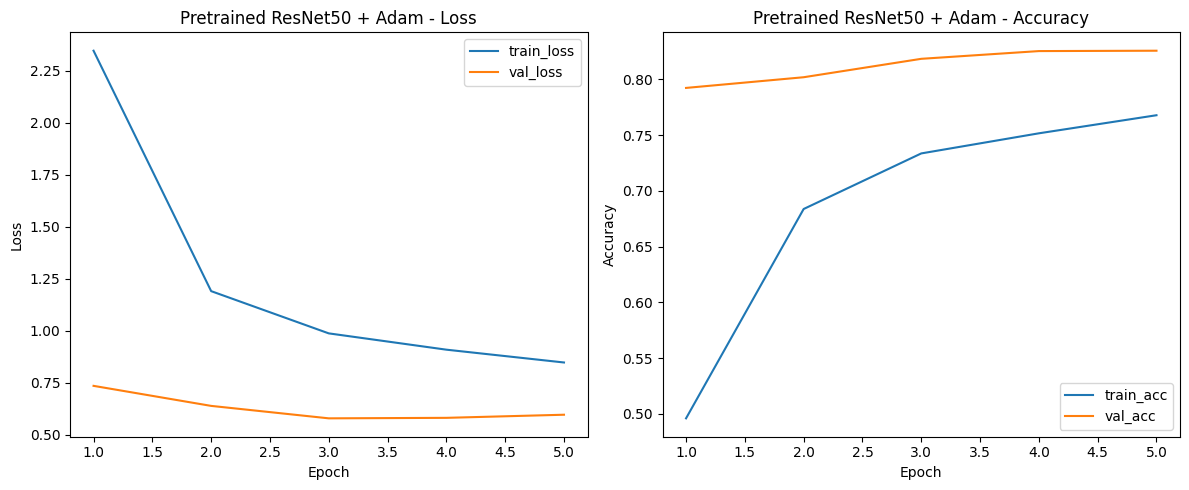

In [26]:
plot_history(history_1, title="Pretrained ResNet50 + Adam")

In [27]:
save_experiment_results(
    exp_name="exp1_pretrained_adam",
    model=model_1,
    history=history_1,
    precision=precision_1,
    recall=recall_1,
    f1=f1_1
)

Saved model to: /content/drive/MyDrive/stanford_dogs_lab/models/exp1_pretrained_adam.pth
Saved metrics to: /content/drive/MyDrive/stanford_dogs_lab/results/exp1_pretrained_adam_metrics.txt
Saved history to: /content/drive/MyDrive/stanford_dogs_lab/results/exp1_pretrained_adam_history.csv


In [28]:
model_2 = build_resnet50(NUM_CLASSES, pretrained=True)

model_2, history_2 = fit_model(
    model=model_2,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=5,
    lr=1e-4,
    optimizer_name="averaged_adam",
    save_name="exp2_pretrained_averaged_adam"
)


Epoch [1/5]


train_loss: 2.3346 | train_acc: 0.5002
val_loss:   0.6975 | val_acc:   0.7815
Best model updated and saved.

Epoch [2/5]


train_loss: 1.1553 | train_acc: 0.6922
val_loss:   0.6289 | val_acc:   0.8069
Best model updated and saved.

Epoch [3/5]


train_loss: 1.0268 | train_acc: 0.7241
val_loss:   0.6346 | val_acc:   0.8017

Epoch [4/5]


train_loss: 0.8901 | train_acc: 0.7553
val_loss:   0.5871 | val_acc:   0.8255
Best model updated and saved.

Epoch [5/5]


train_loss: 0.8294 | train_acc: 0.7740
val_loss:   0.6049 | val_acc:   0.8182


In [29]:
precision_2, recall_2, f1_2, y_true_2, y_pred_2 = get_classification_metrics(model_2, test_loader, device)

print("Experiment 2: Pretrained + Averaged Adam")
print("Precision:", precision_2)
print("Recall:", recall_2)
print("F1:", f1_2)

Experiment 2: Pretrained + Averaged Adam
Precision: 0.8598381989726486
Recall: 0.8495763608797741
F1: 0.8481360298940802


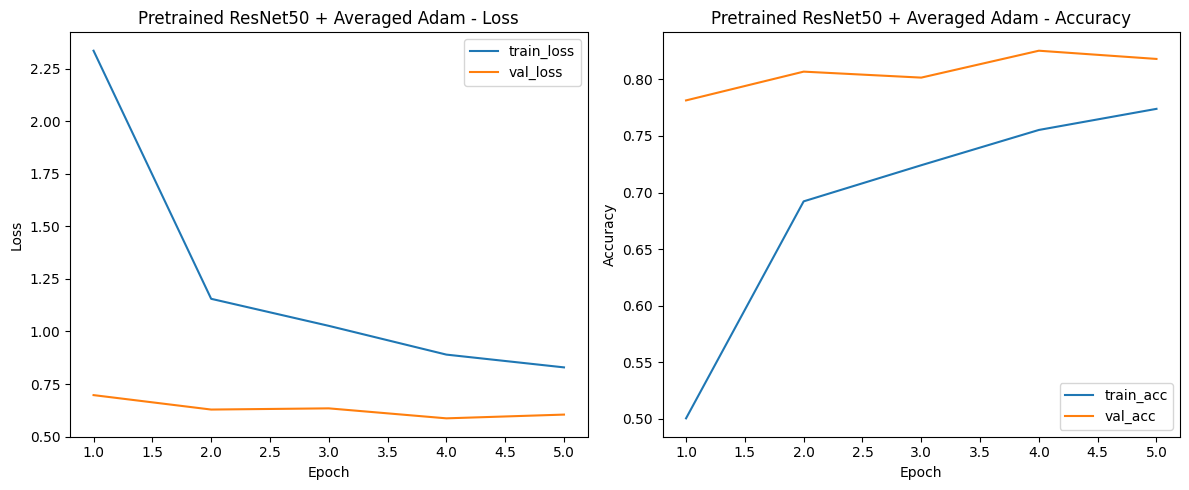

In [30]:
plot_history(history_2, title="Pretrained ResNet50 + Averaged Adam")

In [31]:
save_experiment_results(
    exp_name="exp2_pretrained_averaged_adam",
    model=model_2,
    history=history_2,
    precision=precision_2,
    recall=recall_2,
    f1=f1_2
)

Saved model to: /content/drive/MyDrive/stanford_dogs_lab/models/exp2_pretrained_averaged_adam.pth
Saved metrics to: /content/drive/MyDrive/stanford_dogs_lab/results/exp2_pretrained_averaged_adam_metrics.txt
Saved history to: /content/drive/MyDrive/stanford_dogs_lab/results/exp2_pretrained_averaged_adam_history.csv


In [32]:
model_3 = build_resnet50(NUM_CLASSES, pretrained=False)

model_3, history_3 = fit_model(
    model=model_3,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=5,
    lr=1e-4,
    optimizer_name="adam",
    save_name="exp3_scratch_adam"
)


Epoch [1/5]


train_loss: 4.8102 | train_acc: 0.0169
val_loss:   4.7949 | val_acc:   0.0245
Best model updated and saved.

Epoch [2/5]


train_loss: 4.6190 | train_acc: 0.0307
val_loss:   4.7018 | val_acc:   0.0327
Best model updated and saved.

Epoch [3/5]


train_loss: 4.4929 | train_acc: 0.0399
val_loss:   4.5863 | val_acc:   0.0403
Best model updated and saved.

Epoch [4/5]


train_loss: 4.3669 | train_acc: 0.0476
val_loss:   4.6018 | val_acc:   0.0430
Best model updated and saved.

Epoch [5/5]


train_loss: 4.2425 | train_acc: 0.0672
val_loss:   4.3082 | val_acc:   0.0618
Best model updated and saved.


In [33]:
precision_3, recall_3, f1_3, y_true_3, y_pred_3 = get_classification_metrics(model_3, test_loader, device)

print("Experiment 3: From scratch + Adam")
print("Precision:", precision_3)
print("Recall:", recall_3)
print("F1:", f1_3)

Experiment 3: From scratch + Adam
Precision: 0.0651808573703154
Recall: 0.0571039146181701
F1: 0.03974018617410084


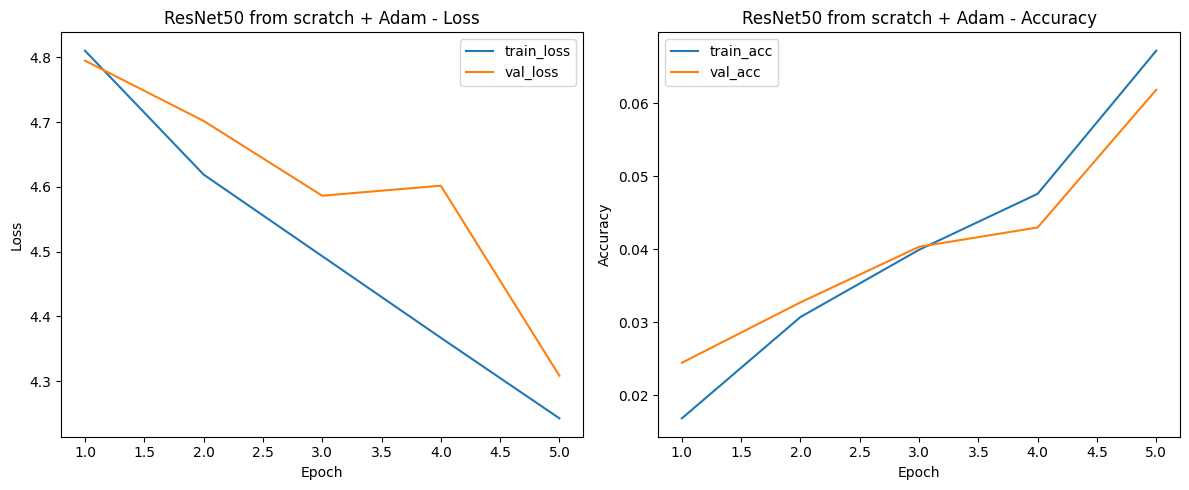

In [34]:
plot_history(history_3, title="ResNet50 from scratch + Adam")

In [35]:
save_experiment_results(
    exp_name="exp3_scratch_adam",
    model=model_3,
    history=history_3,
    precision=precision_3,
    recall=recall_3,
    f1=f1_3
)

Saved model to: /content/drive/MyDrive/stanford_dogs_lab/models/exp3_scratch_adam.pth
Saved metrics to: /content/drive/MyDrive/stanford_dogs_lab/results/exp3_scratch_adam_metrics.txt
Saved history to: /content/drive/MyDrive/stanford_dogs_lab/results/exp3_scratch_adam_history.csv


In [36]:
results = [
    ["Pretrained + Adam", precision_1, recall_1, f1_1],
    ["Pretrained + Averaged Adam", precision_2, recall_2, f1_2],
    ["From scratch + Adam", precision_3, recall_3, f1_3],
]

df_results = pd.DataFrame(results, columns=["Experiment", "Precision", "Recall", "F1"])
df_results

,Experiment,Precision,Recall,F1
0,Pretrained + Adam,0.835037,0.821595,0.820313
1,Pretrained + Averaged Adam,0.859838,0.849576,0.848136
2,From scratch + Adam,0.065181,0.057104,0.039740


In [37]:
results_csv_path = RESULTS_DIR / "final_results.csv"
df_results.to_csv(results_csv_path, index=False)
print("Final results saved to:", results_csv_path)

Final results saved to: /content/drive/MyDrive/stanford_dogs_lab/results/final_results.csv


In [38]:
best_row = df_results.loc[df_results["F1"].idxmax()]
print(best_row)

Experiment    Pretrained + Averaged Adam
Precision                       0.859838
Recall                          0.849576
F1                              0.848136
Name: 1, dtype: object


In [39]:
def save_history_plot(history, title, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

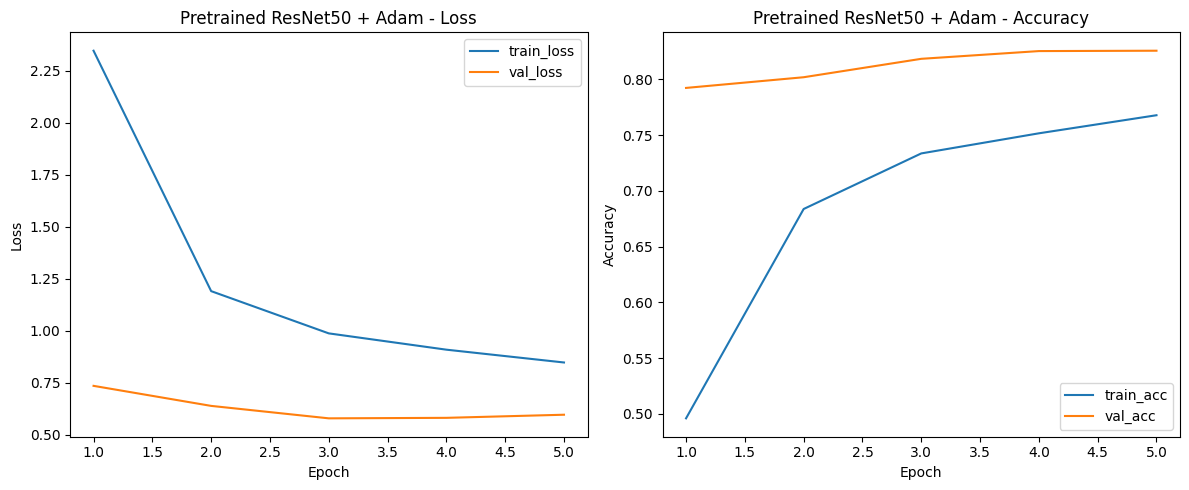

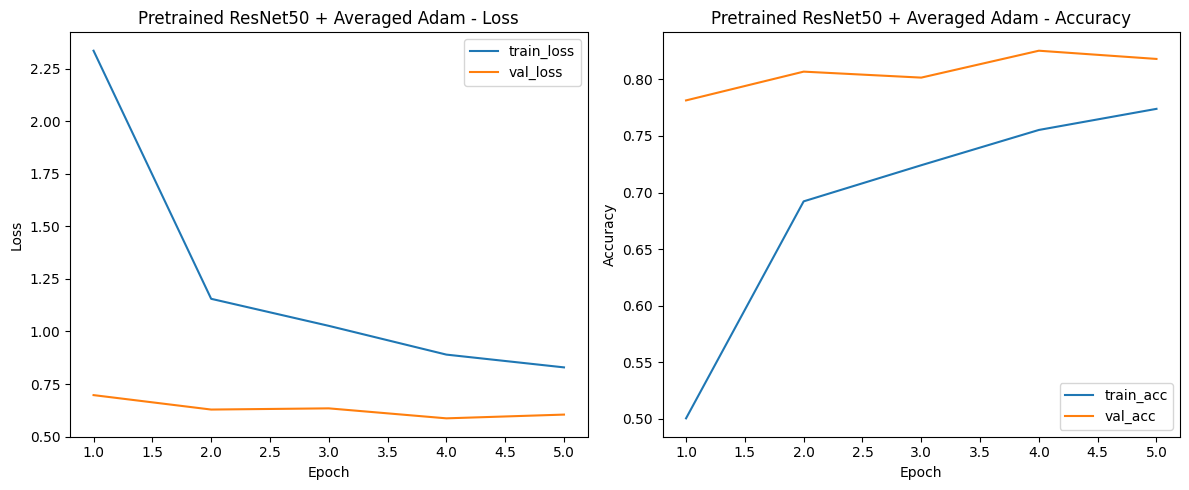

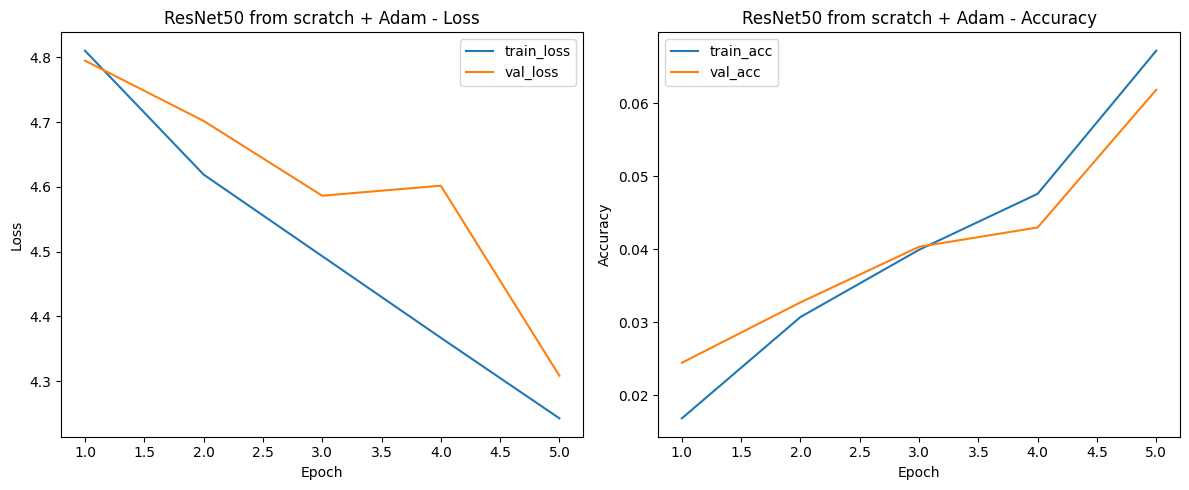

In [40]:
save_history_plot(history_1, "Pretrained ResNet50 + Adam", RESULTS_DIR / "exp1_plot.png")
save_history_plot(history_2, "Pretrained ResNet50 + Averaged Adam", RESULTS_DIR / "exp2_plot.png")
save_history_plot(history_3, "ResNet50 from scratch + Adam", RESULTS_DIR / "exp3_plot.png")

In [41]:
!ls /content/drive/MyDrive/stanford_dogs_lab/models
!ls /content/drive/MyDrive/stanford_dogs_lab/results

exp1_pretrained_adam_best_tmp.pth	    exp2_pretrained_averaged_adam.pth
exp1_pretrained_adam.pth		    exp3_scratch_adam_best_tmp.pth
exp2_pretrained_averaged_adam_best_tmp.pth  exp3_scratch_adam.pth
exp1_plot.png
exp1_pretrained_adam_history.csv
exp1_pretrained_adam_metrics.txt
exp2_plot.png
exp2_pretrained_averaged_adam_history.csv
exp2_pretrained_averaged_adam_metrics.txt
exp3_plot.png
exp3_scratch_adam_history.csv
exp3_scratch_adam_metrics.txt
final_results.csv
